In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Data
#### One note about data is that if sometime the data is large we had to reduce it otherwise it would take a lots of computation power . Another way is to divided the parts in very big chunk which can lead to bigger difference from optimal . Choice is your to take !

##### But in this project i simply divided the bigger input into big chunk which of course led to some difference between the optimal answer and the standard answer 

In [2]:
sq_meter=np.array([130.1,148.6,157.9,174.2,102.2,218.3,227.6,132.4,195.1,260.1])
house_price=np.array([245000,312000,324000,308000,199000,405000,375000,255000,350000,470000])

print(len(sq_meter))
print(len(house_price))

10
10


### Plotting the data

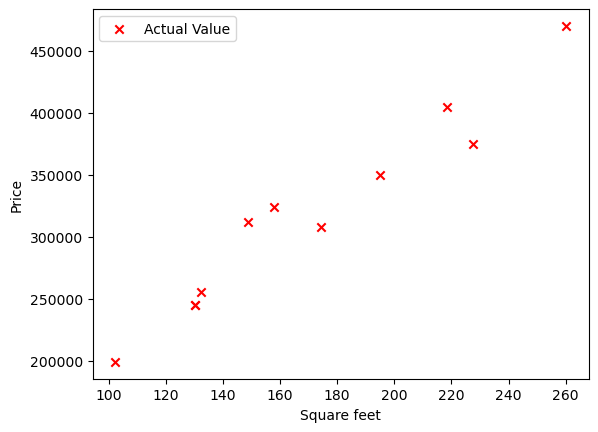

In [3]:
def plotting_data(sq_meter,house_price,a):
    for i in range(0,len(sq_meter)):
        a.scatter(x=sq_meter[i],y=house_price[i],c="red",marker='x')
    a.scatter(x=sq_meter[0],y=house_price[0],c="red",marker="x",label="Actual Value")
    a.set_xlabel("Square feet")
    a.set_ylabel("Price")
    a.legend()

fig,a=plt.subplots()
plotting_data(sq_meter,house_price,a)

#### As this is linear regression we can plot a straight line which will help us to determine the prediction of a price . 
#### **Equation of straight line : y=m*x+c**

In [4]:
def y_val(x,m,c):
    return (m*x)+c

##### But the problem is to find the straight line in the graph we need the straight line slope m and constant c which suit the graph the most according to its data
##### Now the intuition is simple we need an cost function which will calculate the error for every m and c value 
##### cost(m,c)=1/2*s summation of all test case ((y`-y)^2)
#### Lets see the cost function in work with the value for m only means c=0


1836.1836183618361
0


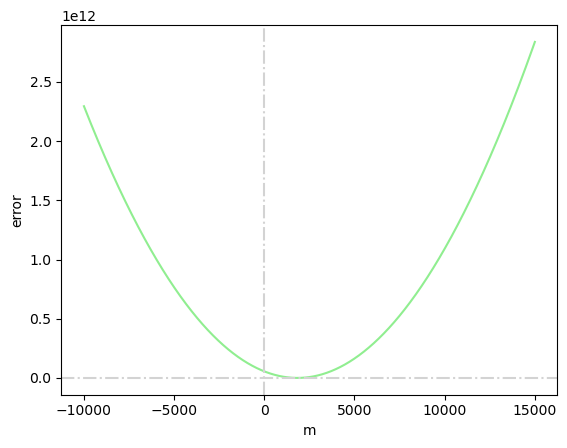

In [10]:
best_m=0
best_c=0
m_c=-1
def cost(m,c,sq_meter,house_price):
    global best_m,m_c,best_c
    sum=0
    for i in range(len(sq_meter)):
        sum+=((house_price[i]-((m*sq_meter[i])+c))**2)
    ret=(1/(2*len(sq_meter)))*sum
    if(m_c==-1 or m_c>abs(ret)):
        best_m=m
        best_c=c
        m_c=abs(ret)
        
    return ret


m=np.linspace(-10000,15000,10000)
y=[]
for i in m:
    y.append(cost(i,0,sq_meter,house_price))
y=np.array(y)
fig,a=plt.subplots()

a.plot(m,y,color="lightgreen")
a.axvline(x=0,c="lightgray",linestyle="-.")
a.axhline(y=0,c="lightgray",linestyle="-.")

a.set_xlabel("m")
a.set_ylabel("error")

print(best_m)
print(best_c)

#### The above graph shows how the error number is changing with the value m and best_m is having the value closest to zero which is we are searching for because this best_m returning the lowest error !

#### As we got best slope for the straight line now lets put in graph and see how close it gets to actual value point

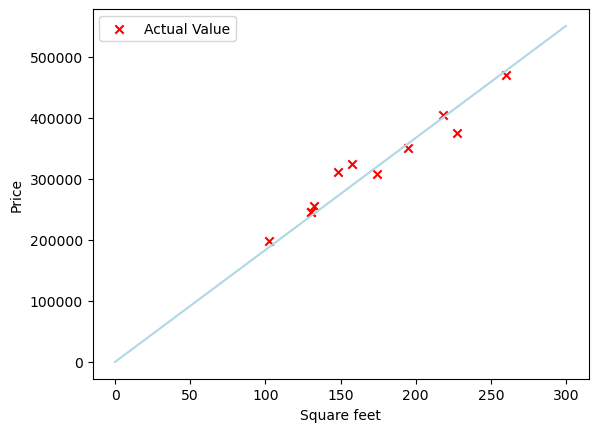

In [6]:
x=np.linspace(0,300,1000)

y=best_m*x

fig,a=plt.subplots()

plotting_data(sq_meter,house_price,a)
a.plot(x,y,c="lightblue")

#### As we can see from the graph above we got a straight line which represent the actual value line or get very close !
#### But this is the straight line we getting just by the slope m we need to also calculate c for the straight line and its corresponding best m and find the most optimal m and c value which represent output of the data most perfectly !


##### Lets try to visualize the corresponding cost y for all the value combination for m and c in a 3d graph 

(1000, 1000)
(1000, 1000)
1571.5715715715723
49849.84984984985
1571.5715715715723
49849.84984984985


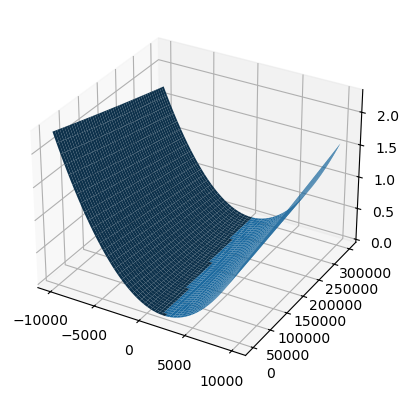

In [ ]:

m=np.linspace(-10000,10000,1000)
c=np.linspace(0,300000,1000)

m,c=np.meshgrid(m,c)
cost_c=[]
for i in range(0,len(c)):
    lst_c=[]
    for j in range(0,len(m[0])):
        lst_c.append(cost(m[i][j],c[i][j],sq_meter,house_price))
    cost_c.append(lst_c)

cost_c=np.array(cost_c)

fig=plt.figure()

a=fig.add_subplot(projection='3d')

a.plot_surface(m,c,cost_c)
print(cost_c.shape)
print(m.shape)


print(best_m)
print(best_c)
my_m=best_m
my_c=best_c



### The graph above shows the error for every corresponding m and c value and we need the m and c which gives us the lowest error value 

#### Lets do the same thing but with numpy array which is far more faster !

#### But this way we cant calculate the best_m and best_c the way we did in brute force as here m and c represent matrix but not an number

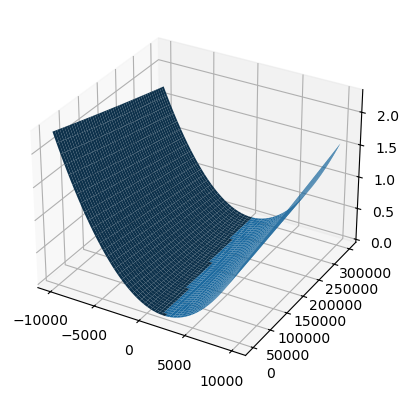

In [62]:
def cost(m,c,sq_meter,house_price):
    error=0
    for i in range(0,len(sq_meter)):
        error+=(house_price[i]-((m*sq_meter[i])+c))**2
    return error/(2*len(sq_meter))

m=np.linspace(-10000,10000,1000)
c=np.linspace(0,300000,1000)

m,c=np.meshgrid(m,c)

z=cost(m,c,sq_meter,house_price)

fig=plt.figure()

a=fig.add_subplot(projection='3d')

a.plot_surface(m,c,z)

##### As we got our m and c value we can successfully plot that line in the graph and *boom* we have our straight line !

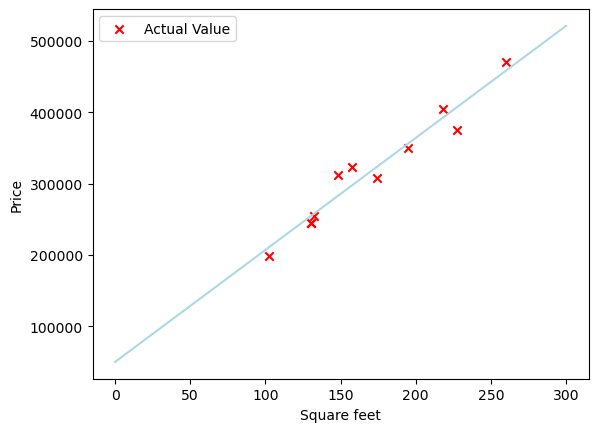

In [ ]:
x=np.linspace(0,300,1000)

y=best_m*x+best_c

fig,a=plt.subplots()

plotting_data(sq_meter,house_price,a)
a.plot(x,y,c="lightblue")

#### This is the equation given by gpt which gives us the best m and c value . And we can see that its pretty close to what we found through brute force

1564.428451472783
51072.57095027843


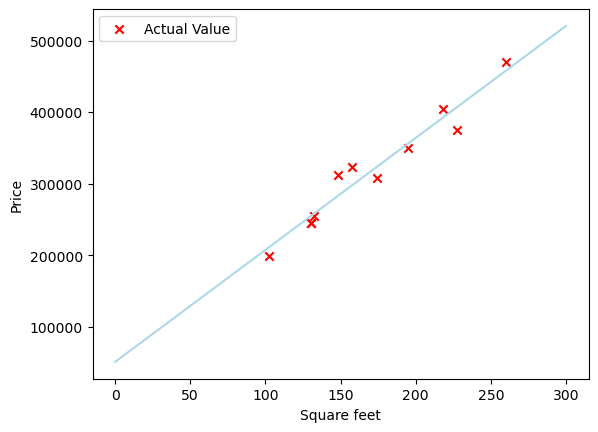

In [68]:

x = np.array(sq_meter)
y = np.array(house_price)

x_mean = np.mean(x)
y_mean = np.mean(y)

m = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
c = y_mean - m*x_mean

print(m)
print(c)

x=np.linspace(0,300,1000)

y=m*x+c

fig,a=plt.subplots()

plotting_data(sq_meter,house_price,a)
a.plot(x,y,c="lightblue")
eq_m=m
eq_c=c

##### Now the main item prediction ! As we got the m and c value this prediction should feel like bread and butter

In [72]:
take=int(input("Enter the house size in square meter : "))
print(f"The house price should be around : {my_m*take+my_c}$ (My prediction)")
print(f"The house price should be around : {eq_m*take+eq_c}$ (Equation prediction)")

The house price should be around : 51421.42142142142$ (My prediction)
The house price should be around : 52636.999401751214$ (Equation prediction)
